In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
!pip install -q kaggle

In [40]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("Kaggle_username")
os.environ["KAGGLE_KEY"] = userdata.get("Kaggle_KEY")


In [41]:
!kaggle datasets download -d biyazejaan/wine-datacsv --unzip

Dataset URL: https://www.kaggle.com/datasets/biyazejaan/wine-datacsv
License(s): unknown
100% 4.44k/4.44k [00:00<00:00, 12.9MB/s]



In [42]:
df = pd.read_csv('wine_data.csv')

In [44]:
# Selection logic that works even if the cell is re-run
if 'class_label' in df.columns:
    df = df[['class_label', 'alcohol', 'malic_acid']]
    df.columns = ['Class label', 'Alcohol', 'Malic acid']

print(df.head())

   Class label  Alcohol  Malic acid
0            1    14.23        1.71
1            1    13.20        1.78
2            1    13.16        2.36
3            1    14.37        1.95
4            1    13.24        2.59


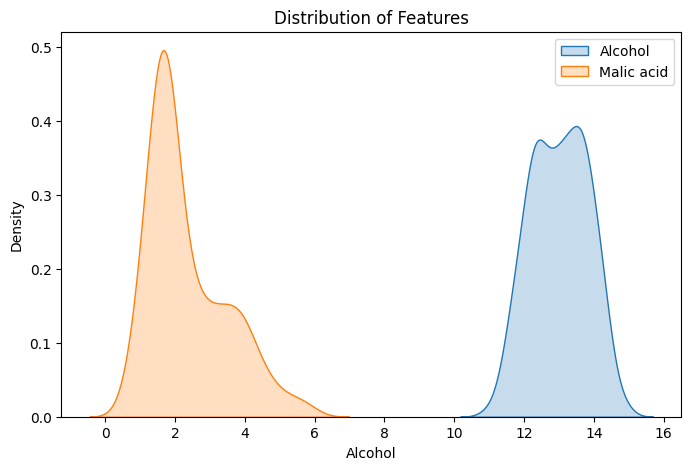

In [45]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x='Alcohol', label='Alcohol', fill=True)
sns.kdeplot(data=df, x='Malic acid', label='Malic acid', fill=True)

plt.title("Distribution of Features")
plt.legend()
plt.show()


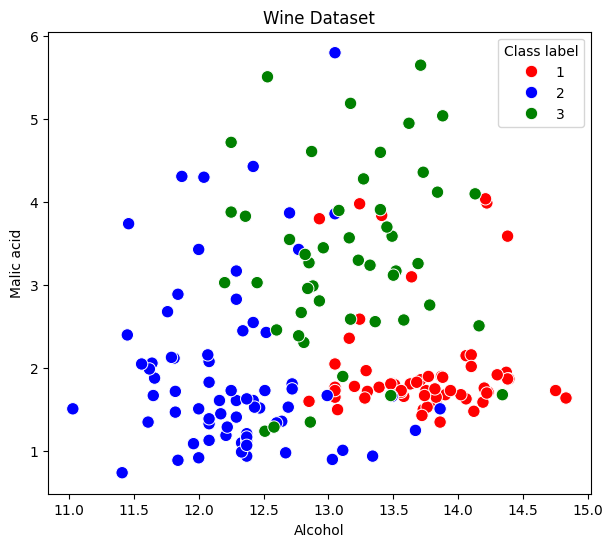

In [46]:
color_dict = {
    1: "red",
    2: "blue",
    3: "green"
}

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic acid',
    hue='Class label',
    palette=color_dict,
    s=80
)

plt.title("Wine Dataset")
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class label', axis=1),
    df['Class label'],
    test_size=0.3,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)

(124, 2)
(54, 2)


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)


In [50]:
print("Before Scaling")
display(np.round(X_train.describe(),2))

print("After Scaling")
display(np.round(X_train_scaled.describe(),2))

Before Scaling


,Alcohol,Malic acid
count,124.00,124.00
mean,12.98,2.38
std,0.80,1.14
min,11.03,0.89
25%,12.36,1.61
50%,13.04,1.88
75%,13.64,3.25
max,14.75,5.65


After Scaling


,Alcohol,Malic acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


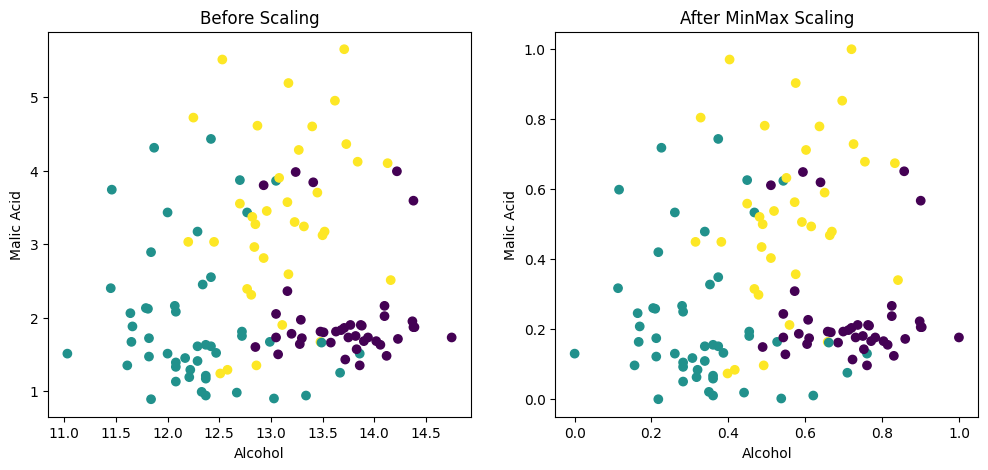

In [51]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

ax1.scatter(
    X_train['Alcohol'],
    X_train['Malic acid'],
    c=y_train.to_numpy(),
    cmap='viridis'
)

ax1.set_title("Before Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic Acid")

ax2.scatter(
    X_train_scaled['Alcohol'],
    X_train_scaled['Malic acid'],
    c=y_train.to_numpy(),
    cmap='viridis'
)

ax2.set_title("After MinMax Scaling")
ax2.set_xlabel("Alcohol")
ax2.set_ylabel("Malic Acid")

plt.show()

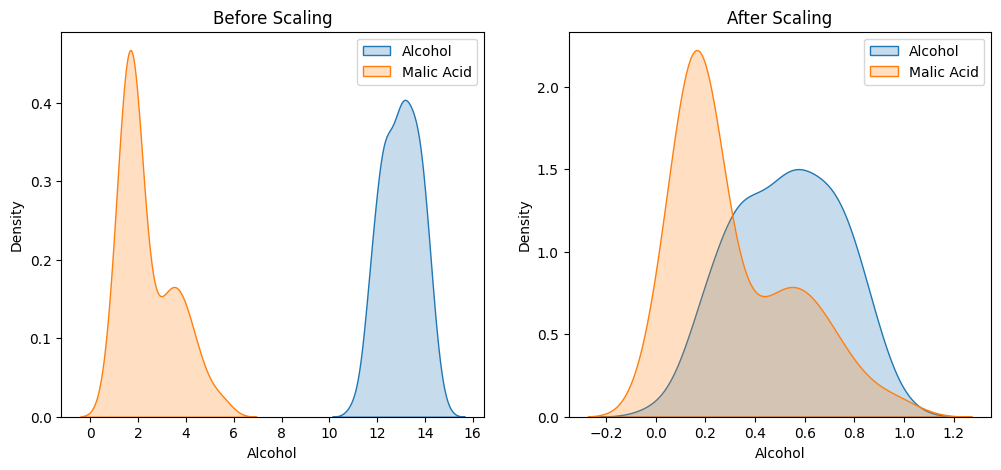

In [52]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

sns.kdeplot(
    data=X_train,
    x='Alcohol',
    ax=ax1,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    data=X_train,
    x='Malic acid',
    ax=ax1,
    label='Malic Acid',
    fill=True
)

ax1.set_title("Before Scaling")
ax1.legend()

sns.kdeplot(
    data=X_train_scaled,
    x='Alcohol',
    ax=ax2,
    label='Alcohol',
    fill=True
)

sns.kdeplot(
    data=X_train_scaled,
    x='Malic acid',
    ax=ax2,
    label='Malic Acid',
    fill=True
)

ax2.set_title("After Scaling")
ax2.legend()

plt.show()

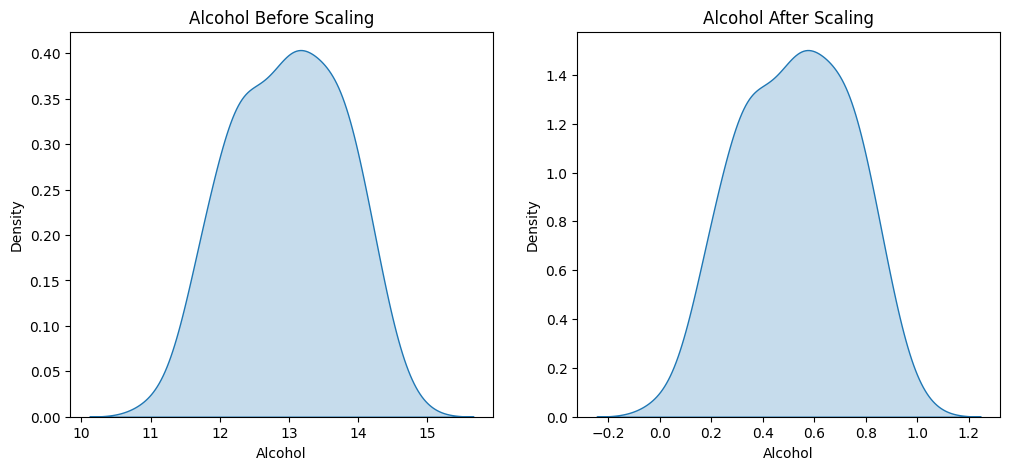

In [53]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

sns.kdeplot(
    data=X_train,
    x='Alcohol',
    fill=True,
    ax=ax1
)

ax1.set_title("Alcohol Before Scaling")

sns.kdeplot(
    data=X_train_scaled,
    x='Alcohol',
    fill=True,
    ax=ax2
)

ax2.set_title("Alcohol After Scaling")

plt.show()


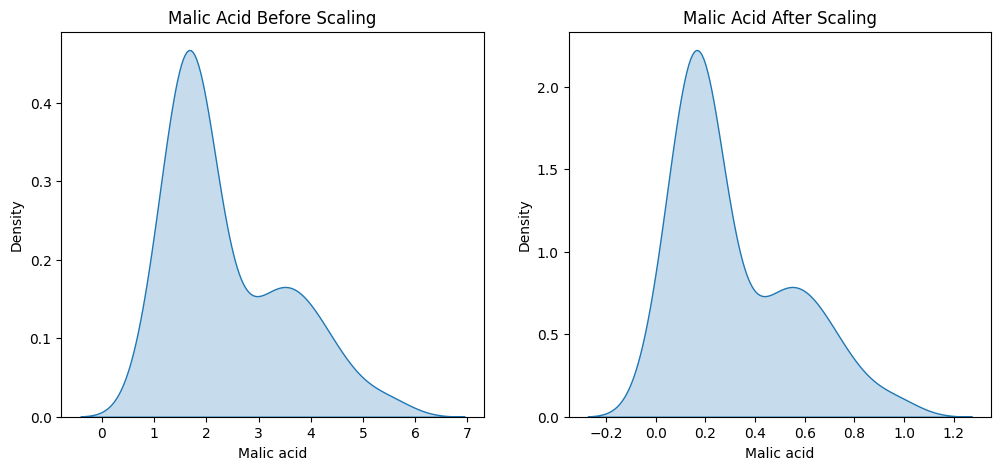

In [54]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

sns.kdeplot(
    data=X_train,
    x='Malic acid',
    fill=True,
    ax=ax1
)

ax1.set_title("Malic Acid Before Scaling")

sns.kdeplot(
    data=X_train_scaled,
    x='Malic acid',
    fill=True,
    ax=ax2
)

ax2.set_title("Malic Acid After Scaling")

plt.show()